#   Vision Classification Pipeline — Computer Vision Project Tracker

##  ✅ Phase 1 — Setup & Data Pipeline

In [38]:
import pandas as pd
train = pd.read_csv('D:\\Coding\\vision-classification-pipeline\\src\\train.csv')
print(train.shape)
print(train.head())
#   each row = one image = 1 label + 784 pixel values

(42000, 785)
   label  pixel0  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  \
0      1       0       0       0       0       0       0       0       0   
1      0       0       0       0       0       0       0       0       0   
2      1       0       0       0       0       0       0       0       0   
3      4       0       0       0       0       0       0       0       0   
4      0       0       0       0       0       0       0       0       0   

   pixel8  ...  pixel774  pixel775  pixel776  pixel777  pixel778  pixel779  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0         0         0         0   
3       0  ...         0         0         0         0         0         0   
4       0  ...         0         0         0         0         0         0   

   pixel780  pixel781  pixel782  pixel783  
0         0      

Label: 0.0


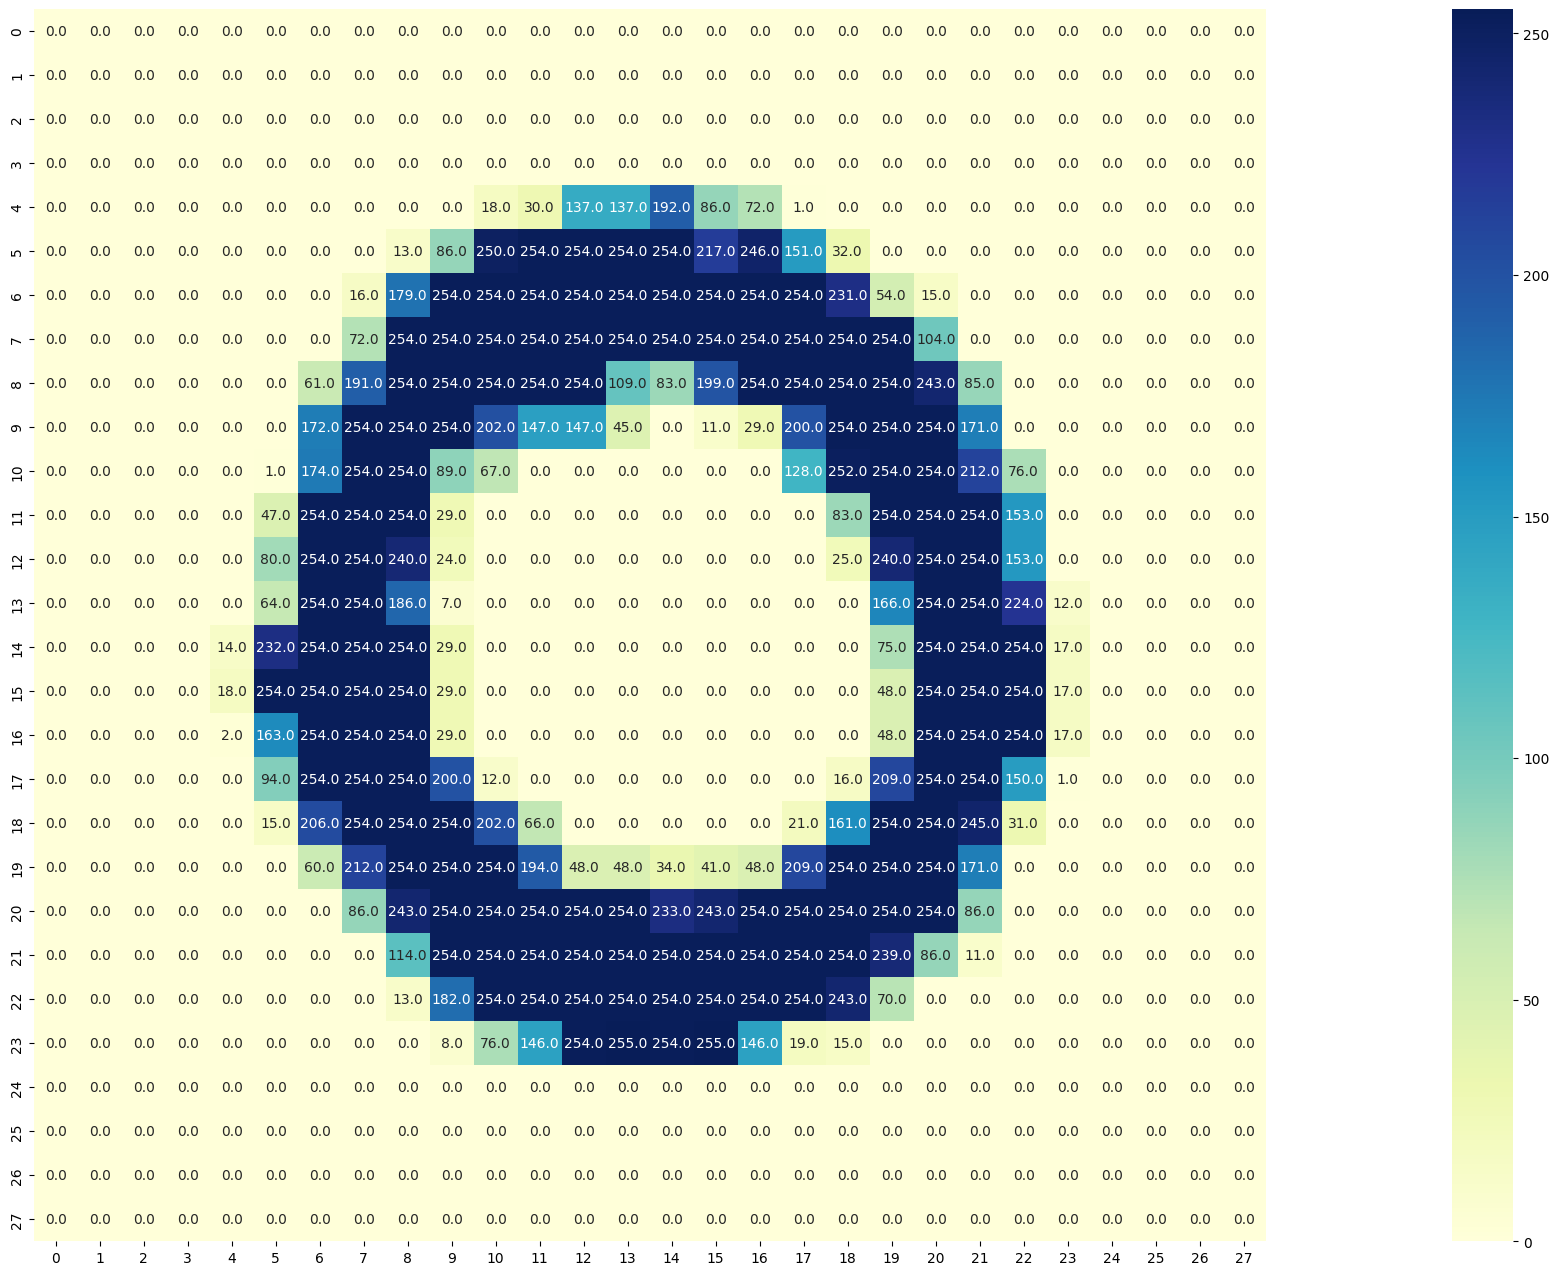

In [39]:
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

# 1. Load the CSV file (Skip the header row if your CSV has one)
# Replace ',' with your actual delimiter if it is different (e.g., ';' or '\t')
data = np.loadtxt('D:\\Coding\\vision-classification-pipeline\\src\\train.csv', delimiter=',', skiprows=1)

# 2. Choose your instance index
i = 1 

# 3. Separate your features (X) and labels (Y) 
# ASSUMPTION: The first column is the label, and the remaining columns are pixels
label = data[i, 0]
flat_image = data[i, 1:]

# 4. Reshape the flat 1D array into a 2D image matrix
# Change (28, 28) to your image's actual height and width dimensions
image = flat_image.reshape(28, 28)

print(f"Label: {label}") 

# 5. Display the heatmap
f, ax = plt.subplots(figsize=(48, 16)) 
sns.heatmap(image, annot=True, fmt='.1f', square=True, cmap="YlGnBu") 
plt.show()


In [40]:
import numpy as np
import matplotlib.pyplot as plt


X = train.drop(columns=['label']).to_numpy(dtype=np.float32)
y = train['label'].to_numpy()

# Reshape all rows into 28x28 images
X_imgs = X.reshape(-1, 28, 28)

print("X shape:", X.shape)
print("X_imgs shape:", X_imgs.shape)
print("label sample:", y[:5])

X shape: (42000, 784)
X_imgs shape: (42000, 28, 28)
label sample: [1 0 1 4 0]


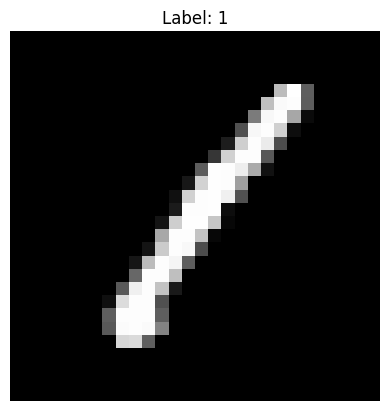

In [41]:
sample_idx = 0
plt.imshow(X_imgs[sample_idx], cmap='gray')
plt.title(f"Label: {y[sample_idx]}")
plt.axis('off')
plt.show()

In [42]:
"""Normalization"""

X = train.drop(columns=['label']).to_numpy(dtype=np.float32)
y = train['label'].to_numpy()

X_norm = X / 255.0
print("Normalized range:", X_norm.min(), X_norm.max())
print("X_norm shape:", X_norm.shape)

X_norm_reshaped = X_norm.reshape(-1, 28, 28, 1)
print("X_norm_reshaped shape:", X_norm_reshaped.shape)

Normalized range: 0.0 1.0
X_norm shape: (42000, 784)
X_norm_reshaped shape: (42000, 28, 28, 1)


In [43]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X_norm_reshaped, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train: (33600, 28, 28, 1)
X_val: (8400, 28, 28, 1)
y_train: (33600,)
y_val: (8400,)


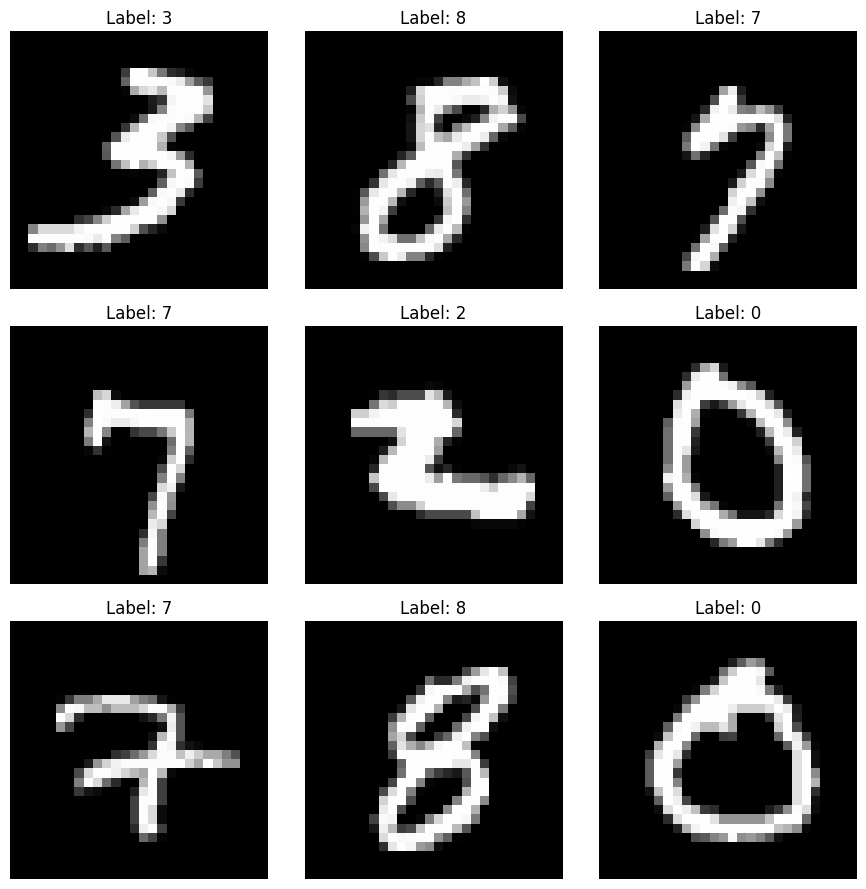

In [44]:
import matplotlib.pyplot as plt
import numpy as np

sample_indices = np.random.choice(len(X_train), 9, replace=False)

fig, axes = plt.subplots(3, 3, figsize=(9, 9))
axes = axes.ravel()

for ax, idx in zip(axes, sample_indices):
    img = X_train[idx].squeeze()
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Label: {y_train[idx]}")
    ax.axis('off')

plt.tight_layout()
plt.show()

##  ✅ Phase 2 — Build CNN

In [45]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([keras.Input(shape=(28, 28, 1)),
                          layers.Conv2D(32, kernel_size= 3, activation= 'relu', padding = 'same'),
                          layers.MaxPooling2D(),
                          layers.Conv2D(filters = 64, kernel_size= 3, activation= 'relu', padding = 'same'),
                          layers.MaxPooling2D(),
                          layers.Flatten(),
                          layers.Dense(128, activation= 'relu'),
                          layers.Dropout(0.3),
                          layers.Dense(10, activation = 'softmax')
                          ])
print(model.summary())

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

None


In [46]:
import os
import shutil

GRAPHVIZ_BIN = r"C:\Program Files\Graphviz\bin"
if os.path.isdir(GRAPHVIZ_BIN):
    os.environ["PATH"] = GRAPHVIZ_BIN + os.pathsep + os.environ.get("PATH", "")

print("dot:", shutil.which("dot"))

dot: C:\Program Files\Graphviz\bin\dot.EXE


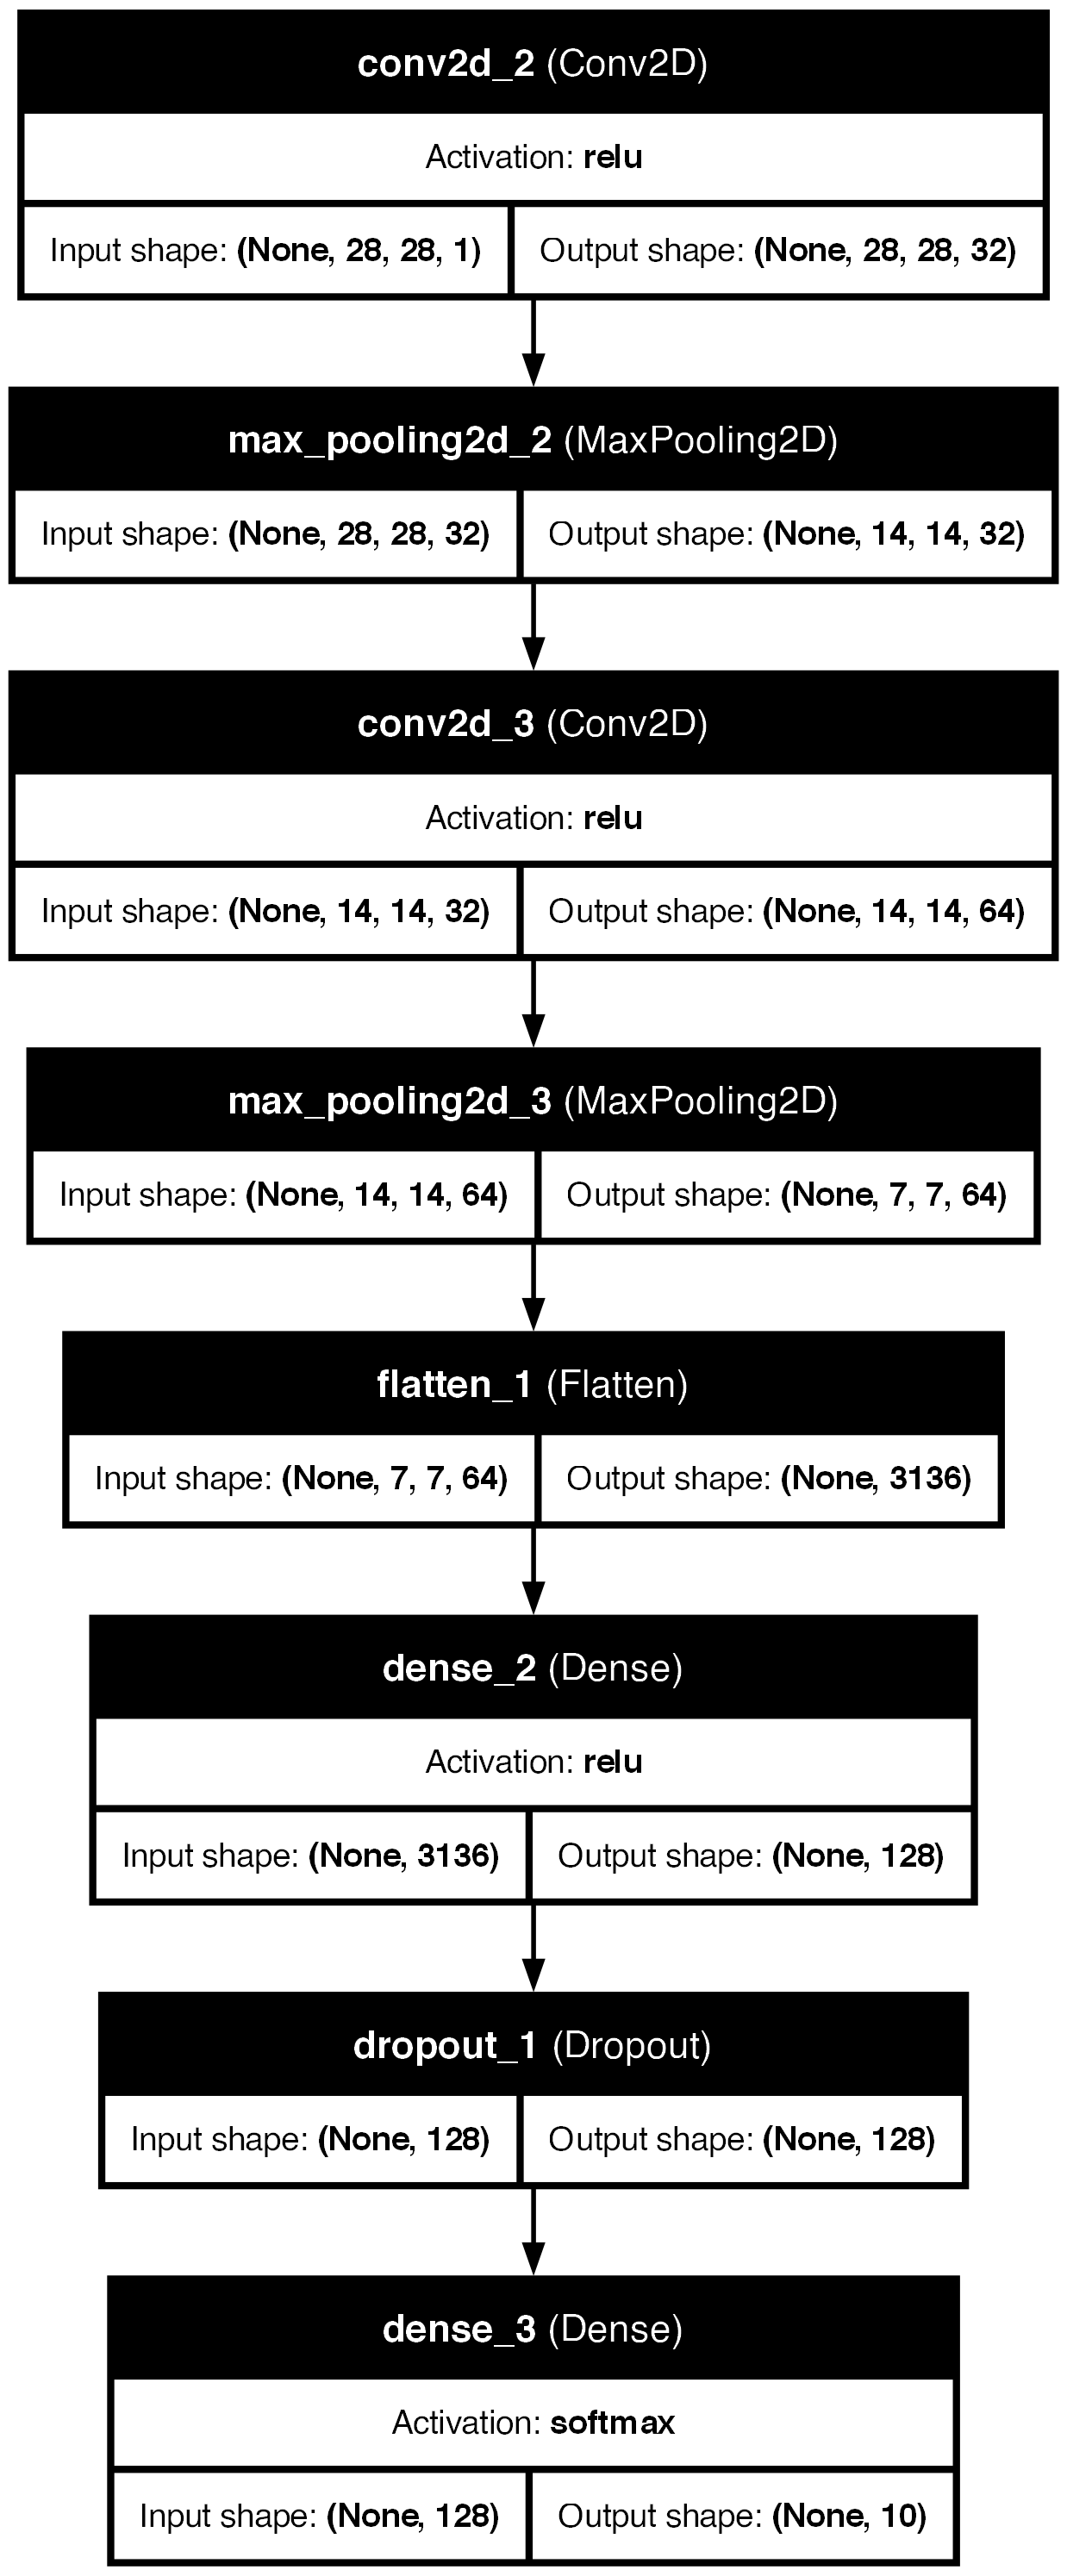

In [47]:
from tensorflow.keras.utils import plot_model

# This will generate the image and display it in your notebook
plot_model(model, 
            
           show_shapes=True, 
           show_layer_names=True,
           show_layer_activations=True)

In [48]:
model.compile(optimizer= 'adam', loss= 'sparse_categorical_crossentropy', metrics = ['accuracy'])
history = model.fit(X_train, y_train, epochs = 10, batch_size= 32, validation_data= (X_val, y_val))


# Access the metrics dictionary
history_dict = history.history

# Print the keys (e.g., 'loss', 'accuracy', 'val_loss', 'val_accuracy')
print(history_dict.keys())
print(history_dict['accuracy'])


Epoch 1/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.9306 - loss: 0.2231 - val_accuracy: 0.9773 - val_loss: 0.0701
Epoch 2/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9775 - loss: 0.0722 - val_accuracy: 0.9825 - val_loss: 0.0559
Epoch 3/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9834 - loss: 0.0516 - val_accuracy: 0.9862 - val_loss: 0.0434
Epoch 4/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9872 - loss: 0.0403 - val_accuracy: 0.9867 - val_loss: 0.0444
Epoch 5/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.9900 - loss: 0.0306 - val_accuracy: 0.9868 - val_loss: 0.0412
Epoch 6/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9920 - loss: 0.0250 - val_accuracy: 0.9871 - val_loss: 0.0470
Epoch 7/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9933 - loss: 0.0202 - val_accuracy: 0.9885 - val_loss: 0.0408
Epoch 8/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9937 - loss: 0.0198 - 

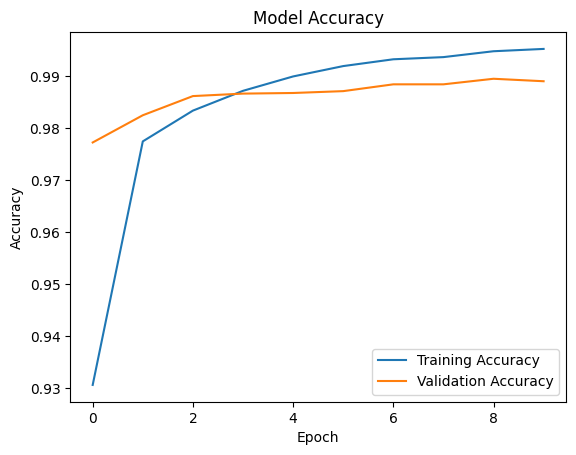

In [49]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

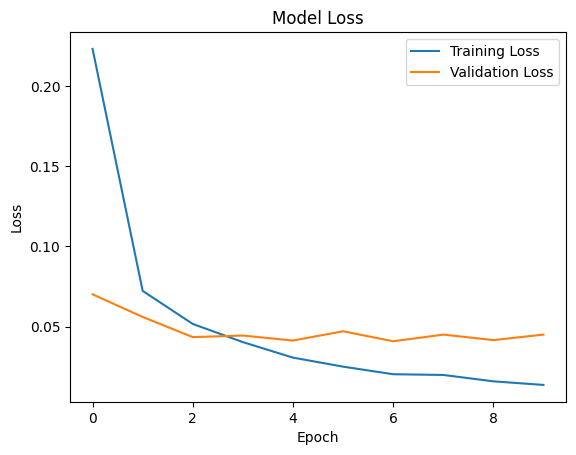

In [50]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()

263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


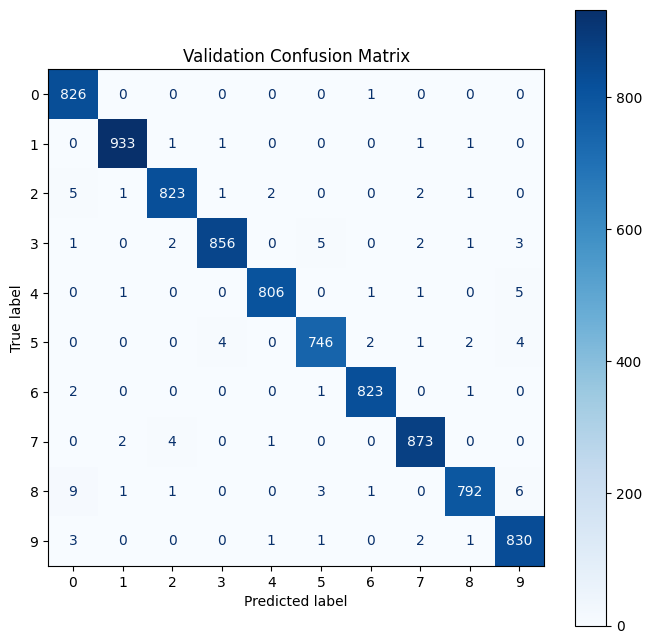

In [51]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

y_val_pred = model.predict(X_val).argmax(axis=1)
cm = confusion_matrix(y_val, y_val_pred)

fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(10)).plot(
    cmap="Blues",
    values_format="d",
    ax=ax
)
ax.set_title("Validation Confusion Matrix")
plt.show()

In [52]:
test = pd.read_csv("D:\\Coding\\vision-classification-pipeline\\src\\test.csv")

X_test = test.to_numpy(dtype=np.float32) / 255.0
X_test = X_test.reshape(-1, 28, 28, 1)

pred_probs = model.predict(X_test)

# This line finds the index of the highest probability for each sample, which corresponds to the predicted class label.
pred_labels = pred_probs.argmax(axis = 1)

submission = pd.DataFrame({
    'ImageID': np.arange(1, len(pred_labels) + 1),
    'Label': pred_labels
})
submission.to_csv("submission.csv", index = False)
submission.head()

875/875 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


,ImageID,Label
0,1,2
1,2,0
2,3,9
3,4,9
4,5,3


### ✅ Phase 3 — Evaluate

263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


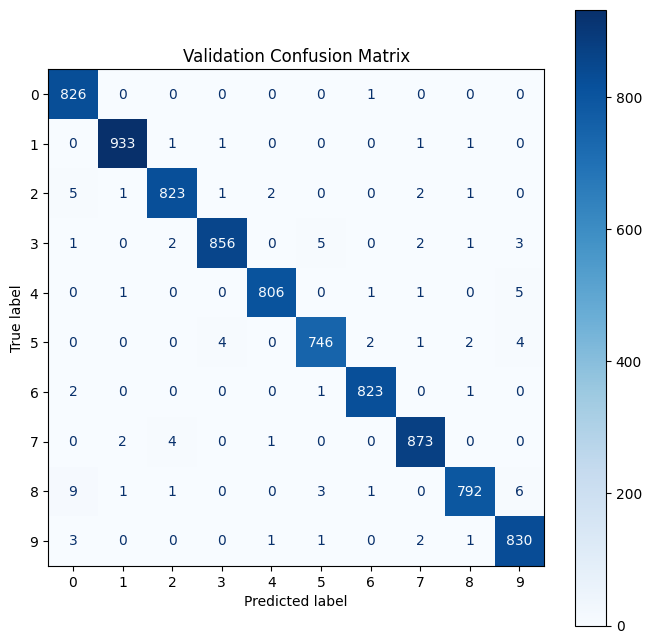

In [53]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

y_val_pred = model.predict(X_val).argmax(axis=1)
cm = confusion_matrix(y_val, y_val_pred)

fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(10)).plot(
    cmap="Blues",
    values_format="d",
    ax=ax
)
ax.set_title("Validation Confusion Matrix")
plt.show()

#### Error analysis: confused digit pairs

In [54]:
# Top 3 true -> predicted digit pairs the model confuses most
cm_pairs = cm.copy()
np.fill_diagonal(cm_pairs, 0)       #   Ignoring Correct Preds
flat_order = np.argsort(cm_pairs.ravel())[::-1] #   Flattening and sorting
top_pairs = []

""" This part identifies the top 3 most frequent confusion pairs (excluding correct predictions)
 It flattens the confusion matrix, sorts indices by count in descending order, and iterates through them
 It stops after collecting 3 pairs or when it encounters a zero count"""
for flat_idx in flat_order:
    true_digit, pred_digit = np.unravel_index(flat_idx, cm_pairs.shape)     #   Finding the top 3

    #   Recording the Mistakes
    count = cm_pairs[true_digit, pred_digit]
    if count == 0:
        break
    top_pairs.append((true_digit, pred_digit, count))
    if len(top_pairs) == 3:
        break

top_confusions = pd.DataFrame(
    top_pairs,
    columns=["true_digit", "predicted_digit", "count"]
)
top_confusions

,true_digit,predicted_digit,count
0,8,0,9
1,8,9,6
2,4,9,5


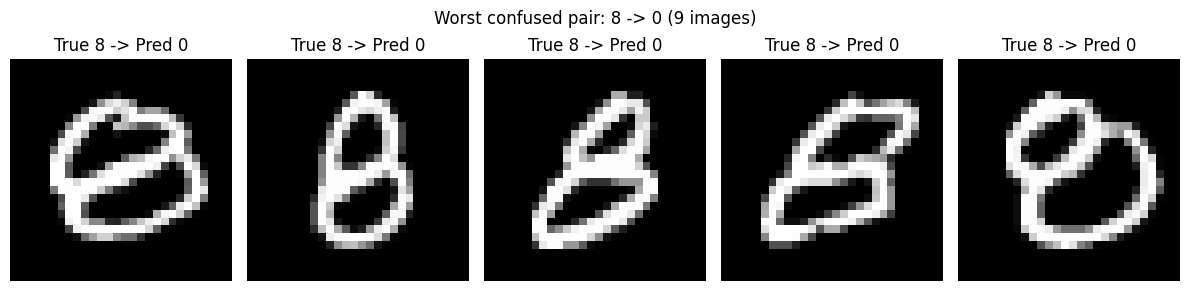

In [55]:
# Display 5 misclassified validation images from the worst confused pair
worst_true, worst_pred, worst_count = top_pairs[0]
worst_pair_indices = np.where((y_val == worst_true) & (y_val_pred == worst_pred))[0][:5]

fig, axes = plt.subplots(1, len(worst_pair_indices), figsize=(12, 3))
axes = np.atleast_1d(axes)

for ax, idx in zip(axes, worst_pair_indices):
    ax.imshow(X_val[idx].squeeze(), cmap="gray")
    ax.set_title(f"True {worst_true} -> Pred {worst_pred}")
    ax.axis("off")

fig.suptitle(f"Worst confused pair: {worst_true} -> {worst_pred} ({worst_count} images)")
plt.tight_layout()
plt.show()

In [56]:
from IPython.display import Markdown, display

display(Markdown(
    f"The model most often confuses **{worst_true}** with **{worst_pred}**. "
    "These digits can look visually similar when the writer uses the same stroke direction, "
    "weak corners, or missing loops, so the small 28x28 image loses details that normally separate them. "
    "The examples above show how handwriting style can blur the boundary between the two classes."
))

The model most often confuses **8** with **0**. These digits can look visually similar when the writer uses the same stroke direction, weak corners, or missing loops, so the small 28x28 image loses details that normally separate them. The examples above show how handwriting style can blur the boundary between the two classes.

#### Per-class precision and recall

In [57]:
from sklearn.metrics import classification_report

report = classification_report(
    y_val,
    y_val_pred,
    labels=np.arange(10),
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).T
class_report = report_df.loc[[str(i) for i in range(10)], ["precision", "recall", "f1-score", "support"]]
class_report

,precision,recall,f1-score,support
0,0.976359,0.998791,0.987448,827.0
1,0.994670,0.995731,0.995200,937.0
2,0.990373,0.985629,0.987995,835.0
3,0.993039,0.983908,0.988453,870.0
4,0.995062,0.990172,0.992611,814.0
5,0.986772,0.982872,0.984818,759.0
6,0.993961,0.995163,0.994562,827.0
7,0.989796,0.992045,0.990919,880.0
8,0.991239,0.974170,0.982630,813.0
9,0.978774,0.990453,0.984579,838.0


In [58]:
lowest_recall_digit = class_report["recall"].idxmin()
lowest_recall = class_report.loc[lowest_recall_digit, "recall"]

print(f"Hardest class by recall: digit {lowest_recall_digit} (recall = {lowest_recall:.3f})")

Hardest class by recall: digit 8 (recall = 0.974)


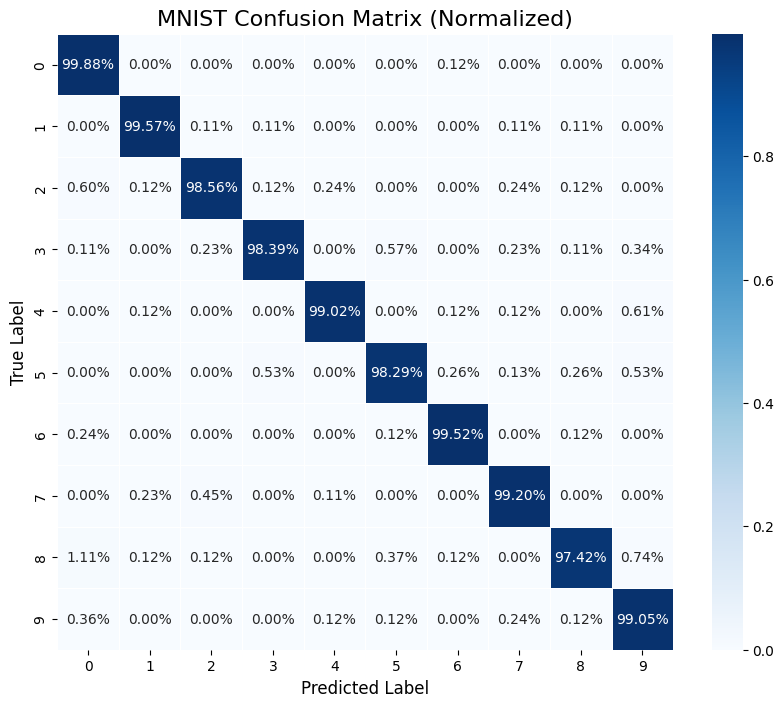

In [59]:
import seaborn as sns

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# 3. Create a pandas DataFrame for easy labeling in Seaborn
classes = [str(i) for i in range(10)]
cm_df = pd.DataFrame(cm_norm, index=classes, columns=classes)


plt.figure(figsize=(10, 8))
sns.heatmap(cm_df, annot=True, fmt='.2%', cmap='Blues', cbar=True,
            linewidths=0.5, square=True)

plt.title('MNIST Confusion Matrix (Normalized)', fontsize=16)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.show()

**What's the difference between precision and recall? Which one matters more here and why?**

Precision asks: “When the model predicts a digit, how often is it right?"

Example: if the model predicts 9 100 times and 92 of those are actually 9, precision for 9 is 0.92.

Recall asks: “Out of all real examples of a digit, how many did the model find?”

Example: if there are 100 actual 9s and the model correctly identifies 88 of them, recall for 9 is 0.88.

For this digit classifier, recall matters more for finding the hardest digit, because low recall means the model is missing many real examples of that digit and confusing them with other classes. Precision is still useful, but recall directly answers: “Which true digit does the model struggle to recognize?”
Precision asks: “When the model predicts a digit, how often is it right?”

Example: if the model predicts 9 100 times and 92 of those are actually 9, precision for 9 is 0.92.

Recall asks: “Out of all real examples of a digit, how many did the model find?”

Example: if there are 100 actual 9s and the model correctly identifies 88 of them, recall for 9 is 0.88.

For this digit classifier, recall matters more for finding the hardest digit, because low recall means the model is missing many real examples of that digit and confusing them with other classes. Precision is still useful, but recall directly answers: “Which true digit does the model struggle to recognize?”

##  Phase 4 — Data Augmentation

### Train with augmentation

This model sees small rotated, zoomed, and shifted versions of the training images.

In [61]:
# Train a new model with simple data augmentation
augmented_model = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.08),
    layers.RandomTranslation(0.08, 0.08),
    layers.Conv2D(32, kernel_size=3, activation='relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, kernel_size=3, activation='relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

augmented_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

aug_history = augmented_model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_val, y_val)
)

Epoch 1/15
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.8623 - loss: 0.4267 - val_accuracy: 0.9752 - val_loss: 0.0771
Epoch 2/15
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.9478 - loss: 0.1734 - val_accuracy: 0.9826 - val_loss: 0.0550
Epoch 3/15
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.9580 - loss: 0.1380 - val_accuracy: 0.9844 - val_loss: 0.0506
Epoch 4/15
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.9640 - loss: 0.1155 - val_accuracy: 0.9838 - val_loss: 0.0527
Epoch 5/15
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9688 - loss: 0.1011 - val_accuracy: 0.9868 - val_loss: 0.0475
Epoch 6/15
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.9701 - loss: 0.0961 - val_accuracy: 0.9888 - val_loss: 0.0359
Epoch 7/15
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.9737 - loss: 0.0883 - val_accuracy: 0.9883 - val_loss: 0.0373
Epoch 8/15
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.9758 - loss: 0.0772 - 

### Compare accuracy curves

The baseline model used `history`. The augmented model used `aug_history`.

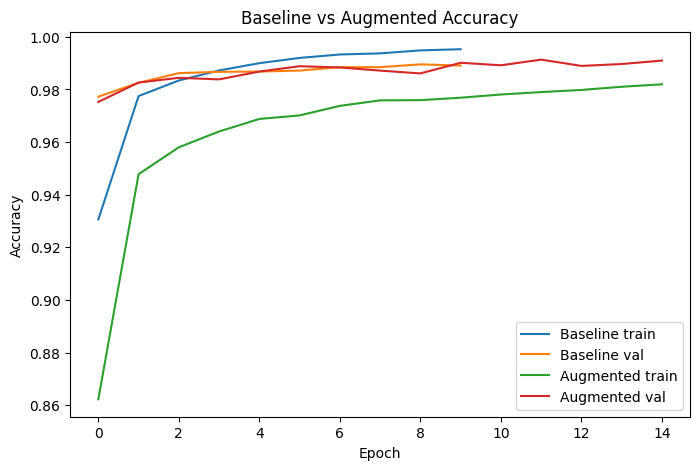

In [62]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Baseline train')
plt.plot(history.history['val_accuracy'], label='Baseline val')
plt.plot(aug_history.history['accuracy'], label='Augmented train')
plt.plot(aug_history.history['val_accuracy'], label='Augmented val')

plt.title('Baseline vs Augmented Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

### Check validation accuracy and the train-val gap

A smaller gap usually means the model is overfitting less.

In [63]:
baseline_val_acc = history.history['val_accuracy'][-1]
aug_val_acc = aug_history.history['val_accuracy'][-1]

baseline_gap = history.history['accuracy'][-1] - history.history['val_accuracy'][-1]
aug_gap = aug_history.history['accuracy'][-1] - aug_history.history['val_accuracy'][-1]

print(f"Baseline final val accuracy:  {baseline_val_acc:.4f}")
print(f"Augmented final val accuracy: {aug_val_acc:.4f}")
print()
print(f"Baseline train-val gap:  {baseline_gap:.4f}")
print(f"Augmented train-val gap: {aug_gap:.4f}")
print()

if aug_val_acc > baseline_val_acc:
    print('Validation accuracy improved.')
else:
    print('Validation accuracy did not improve.')

if aug_gap < baseline_gap:
    print('The train-val gap shrank.')
else:
    print('The train-val gap did not shrink.')

Baseline final val accuracy:  0.9890
Augmented final val accuracy: 0.9910

Baseline train-val gap:  0.0062
Augmented train-val gap: -0.0090

Validation accuracy improved.
The train-val gap shrank.


### Short note

I think rotation helped most because handwritten digits are often slightly tilted. Small rotations teach the model that a tilted digit is still the same digit, so it should generalize better to new handwriting.

### Create Kaggle submission file

Use the augmented model to predict the test images, then save the predictions in Kaggle format.

In [ ]:
# Load the Kaggle test file
test = pd.read_csv('D:\\Coding\\vision-classification-pipeline\\src\\test.csv')

# Prepare the test images the same way as the training images
X_test = test.to_numpy(dtype=np.float32) / 255.0
X_test = X_test.reshape(-1, 28, 28, 1)

# Predict with the augmented model
pred_probs = augmented_model.predict(X_test)
pred_labels = pred_probs.argmax(axis=1)

# Create the Kaggle submission table
submission = pd.DataFrame({
    'ImageId': np.arange(1, len(pred_labels) + 1),
    'Label': pred_labels
})

# Save the file
submission.to_csv('D:\\Coding\\vision-classification-pipeline\\submission_file\\kaggle_submission_augmented.csv', index=False)

submission.head()